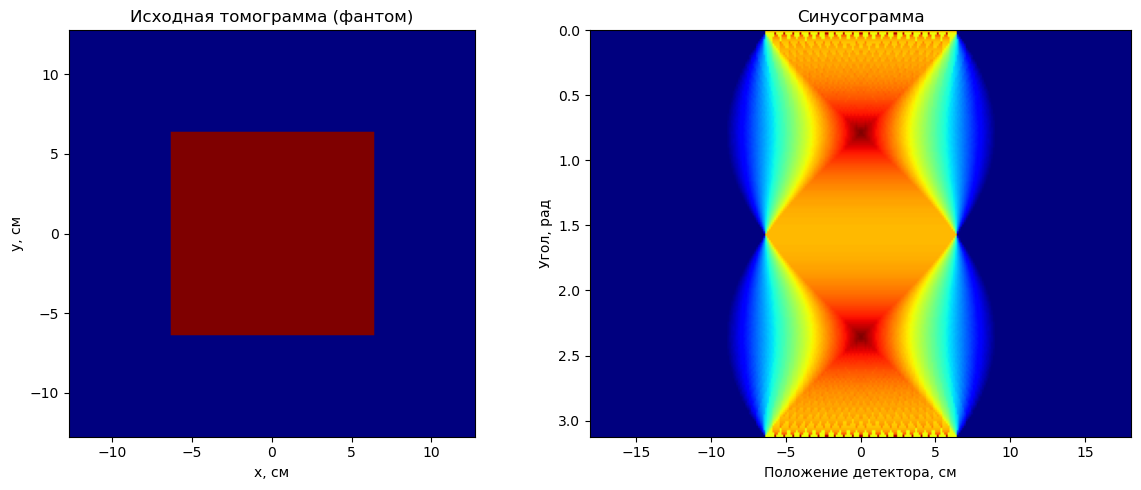

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os

# Загружаем фантом или создаем тестовый квадрат
if os.path.exists('phantom.mat'):
    data = sio.loadmat('phantom.mat')
    phantom = data['phantom']
    delta = float(data['delta'])
    M, N = phantom.shape
else:
    M, N = 256, 256
    delta = 0.1
    phantom = np.zeros((M, N))
    phantom[64:192, 64:192] = 1.0

# Параметры сканирования
num_angles = 180
num_detectors = 300

angles = np.linspace(0, np.pi, num_angles, endpoint=False)
L = N * delta
xi_max = (np.sqrt(2) / 2) * L
detectors = np.linspace(-xi_max, xi_max, num_detectors)

sinogram = np.zeros((num_angles, num_detectors))

# Координаты сетки
x_phys = (np.arange(1, N + 1) - (N + 1) / 2) * delta
y_phys = ((M + 1) / 2 - np.arange(1, M + 1)) * delta

x_edges = np.append(x_phys - delta/2, x_phys[-1] + delta/2)
y_edges = np.append(y_phys + delta/2, y_phys[-1] - delta/2)

# Расчет синусограммы
for k in range(num_angles):
    theta = angles[k]
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    
    for j in range(num_detectors):
        xi = detectors[j]
        
        # Основной случай
        if abs(sin_t) > 1e-6:
            y_inter = (xi - x_edges * cos_t) / sin_t
            dx = np.diff(x_edges)
            dy = np.diff(y_inter)
            lengths = np.sqrt(dx**2 + dy**2)
            
            y_mid = (xi - x_phys * cos_t) / sin_t
            
            for ix in range(N):
                ym = y_mid[ix]
                if y_edges[-1] <= ym <= y_edges[0]:
                    iy = np.searchsorted(-y_edges, -ym) - 1
                    if 0 <= iy < M:
                        sinogram[k, j] += phantom[iy, ix] * lengths[ix]
        # Вертикальные лучи
        else:
            idx = np.searchsorted(x_edges, xi) - 1
            if 0 <= idx < N:
                sinogram[k, j] = np.sum(phantom[:, idx]) * delta

# Сохраняем результат
sio.savemat('sinogram.mat', {
    'sinogram': sinogram, 
    'angles': angles, 
    'detector_pos': detectors
})

# Отрисовка
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(phantom, extent=[x_phys[0], x_phys[-1], y_phys[-1], y_phys[0]], cmap='jet')
ax1.set_title('Исходная томограмма (фантом)')
ax1.set_xlabel('x, см')
ax1.set_ylabel('y, см')

ax2.imshow(sinogram, extent=[detectors[0], detectors[-1], angles[-1], angles[0]], cmap='jet', aspect='auto')
ax2.set_title('Синусограмма')
ax2.set_xlabel('Положение детектора, см')
ax2.set_ylabel('Угол, рад')

plt.tight_layout()
plt.show()